# Tarefa de Python: Aplicação do Algoritmo DBSCAN em Dados Sintéticos

**Aluno:** Cauê Reis

**Disciplina:** Aprendizado Não Supervisionado / Análise de Agrupamentos

## Objetivo

Aplicar o algoritmo DBSCAN a três conjuntos de dados sintéticos (`make_moons`, `make_circles`, `make_blobs`), analisando como os parâmetros `eps` e `min_samples` influenciam a formação dos agrupamentos, a identificação de ruído e a qualidade dos resultados.

## 0. Importações e Configurações

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COR_RUIDO = '#AAAAAA'
CORES_CLUSTERS = ['#1565C0', '#E53935', '#2E7D32', '#F57F17', '#6A1B9A', '#00838F']

def cor_cluster(label):
    if label == -1:
        return COR_RUIDO
    return CORES_CLUSTERS[label % len(CORES_CLUSTERS)]

## 1. Geração dos Dados Sintéticos

In [ ]:
# --- Dados 1: Duas luas intercaladas ---
X_moons, y_moons = make_moons(n_samples=400, noise=0.08, random_state=42)

# --- Dados 2: Círculos concêntricos ---
X_circles, y_circles = make_circles(n_samples=400, factor=0.45, noise=0.06, random_state=42)

# --- Dados 3: Blobs gaussianos + ruído artificial ---
X_blobs, y_blobs = make_blobs(
    n_samples=350, centers=3,
    cluster_std=[0.55, 0.75, 0.60],
    random_state=42
)
ruido = np.random.RandomState(42).uniform(low=-8, high=8, size=(50, 2))
X_blobs_ruido = np.vstack([X_blobs, ruido])
y_blobs_ruido = np.concatenate([y_blobs, np.repeat(-1, 50)])

print('Resumo das bases geradas:')
print(f'  Dados 1 (moons)    : {X_moons.shape[0]} amostras, 2 classes reais')
print(f'  Dados 2 (circles)  : {X_circles.shape[0]} amostras, 2 classes reais')
print(f'  Dados 3 (blobs+ruído): {X_blobs_ruido.shape[0]} amostras '
      f'(350 blob + 50 ruído), 3 classes reais + outliers')

Resumo das bases geradas:
  Dados 1 (moons)    : 400 amostras, 2 classes reais
  Dados 2 (circles)  : 400 amostras, 2 classes reais
  Dados 3 (blobs+ruído): 400 amostras (350 blob + 50 ruído), 3 classes reais + outliers


## 2. Etapa 1 — Exploração Inicial: Visualização dos Dados Originais

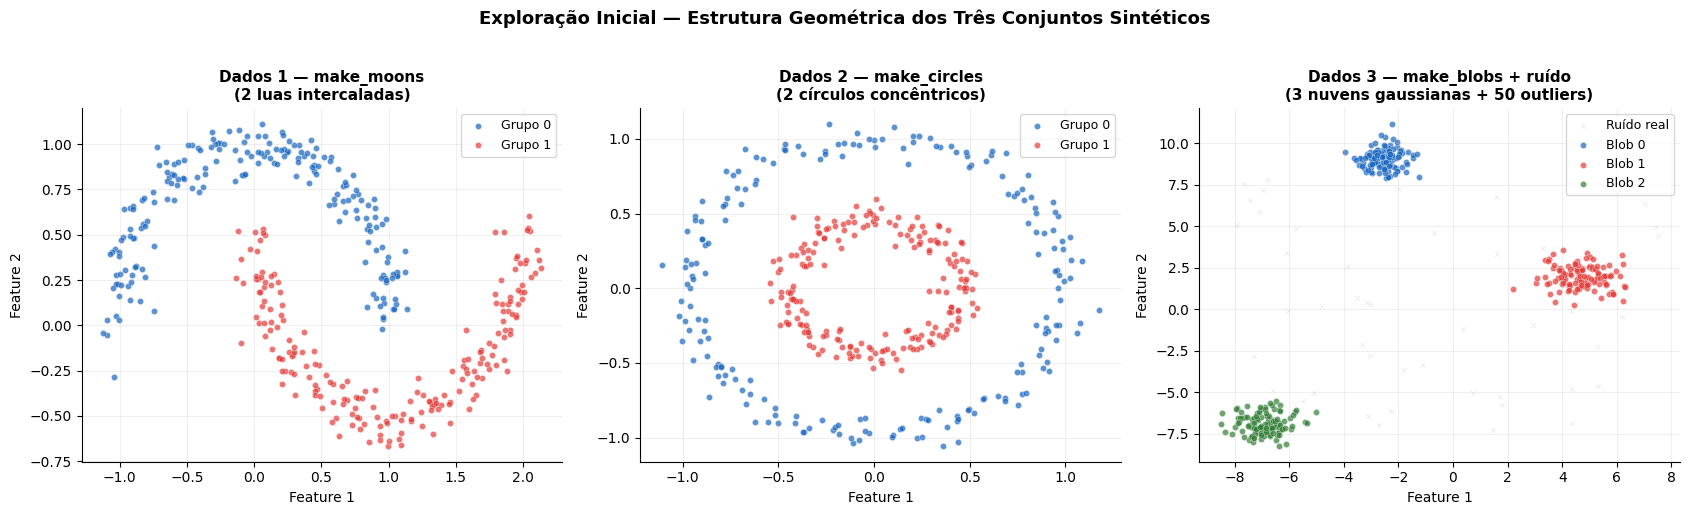

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Dados 1 — Moons
ax = axes[0]
for label in np.unique(y_moons):
    mask = y_moons == label
    ax.scatter(X_moons[mask, 0], X_moons[mask, 1],
               c=CORES_CLUSTERS[label], s=20, alpha=0.7,
               label=f'Grupo {label}', edgecolors='white', linewidths=0.3)
ax.set_title('Dados 1 — make_moons\n(2 luas intercaladas)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.grid(alpha=0.2)

# Dados 2 — Circles
ax = axes[1]
for label in np.unique(y_circles):
    mask = y_circles == label
    ax.scatter(X_circles[mask, 0], X_circles[mask, 1],
               c=CORES_CLUSTERS[label], s=20, alpha=0.7,
               label=f'Grupo {label}', edgecolors='white', linewidths=0.3)
ax.set_title('Dados 2 — make_circles\n(2 círculos concêntricos)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.grid(alpha=0.2)

# Dados 3 — Blobs + ruído
ax = axes[2]
cores_true = {0: CORES_CLUSTERS[0], 1: CORES_CLUSTERS[1], 2: CORES_CLUSTERS[2], -1: COR_RUIDO}
rotulos_true = {0: 'Blob 0', 1: 'Blob 1', 2: 'Blob 2', -1: 'Ruído real'}
for label in [-1, 0, 1, 2]:
    mask = y_blobs_ruido == label
    ax.scatter(X_blobs_ruido[mask, 0], X_blobs_ruido[mask, 1],
               c=cores_true[label], s=20 if label != -1 else 12,
               alpha=0.7 if label != -1 else 0.4,
               label=rotulos_true[label], edgecolors='white', linewidths=0.3,
               marker='o' if label != -1 else 'x')
ax.set_title('Dados 3 — make_blobs + ruído\n(3 nuvens gaussianas + 50 outliers)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
ax.grid(alpha=0.2)

plt.suptitle('Exploração Inicial — Estrutura Geométrica dos Três Conjuntos Sintéticos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretação visual:**

- **Dados 1 (moons):** Os dois grupos formam curvas em meia-lua que se entrelaçam. Nenhuma fronteira linear ou elíptica conseguiria separá-los; algoritmos que assumem convexidade (como K-means) falhariam aqui. O DBSCAN, ao seguir regiões de alta densidade, é naturalmente adequado.
- **Dados 2 (circles):** Um grupo envolve completamente o outro em formato circular. A separabilidade é zero por distância euclidiana ao centróide — o K-means jamais os separaria. O DBSCAN consegue distinguir círculos desde que a distância entre eles (`factor`) seja maior que o `eps` utilizado.
- **Dados 3 (blobs + ruído):** Três nuvens aproximadamente gaussianas com pontos espalhados uniformemente no espaço como ruído. Este é o cenário mais parecido com os pressupostos do K-means, mas a presença explícita de outliers é um teste crítico para a robustez do método.

## 3. Etapa 2 — Padronização dos Dados (StandardScaler)

In [ ]:
scaler = StandardScaler()

X_moons_s    = scaler.fit_transform(X_moons)
X_circles_s  = scaler.fit_transform(X_circles)
X_blobs_s    = scaler.fit_transform(X_blobs_ruido)

print('Estatísticas antes e depois da padronização (Dados 1 — moons):')
print(f'  Antes  — Média: {X_moons.mean(axis=0).round(3)}, Desvio: {X_moons.std(axis=0).round(3)}')
print(f'  Depois — Média: {X_moons_s.mean(axis=0).round(6)}, Desvio: {X_moons_s.std(axis=0).round(6)}')
print()
print('Estatísticas antes e depois da padronização (Dados 3 — blobs):')
print(f'  Antes  — Média: {X_blobs_ruido.mean(axis=0).round(3)}, Desvio: {X_blobs_ruido.std(axis=0).round(3)}')
print(f'  Depois — Média: {X_blobs_s.mean(axis=0).round(6)}, Desvio: {X_blobs_s.std(axis=0).round(6)}')

Estatísticas antes e depois da padronização (Dados 1 — moons):
  Antes  — Média: [0.508 0.253], Desvio: [0.874 0.501]
  Depois — Média: [-0. -0.], Desvio: [1. 1.]

Estatísticas antes e depois da padronização (Dados 3 — blobs):
  Antes  — Média: [-1.501  1.214], Desvio: [4.822 6.359]
  Depois — Média: [-0.  0.], Desvio: [1. 1.]


**Por que a padronização é essencial no DBSCAN?**

O DBSCAN define vizinhança por meio de uma distância (tipicamente euclidiana) controlada pelo parâmetro `eps`. Se as variáveis estiverem em escalas muito diferentes — por exemplo, uma em centímetros e outra em quilômetros —, a distância euclidiana será dominada pela variável de maior magnitude, tornando o `eps` sem significado físico uniforme.

Após o `StandardScaler`, todas as variáveis têm **média 0 e desvio-padrão 1**, de modo que `eps=0.20` representa a mesma proporção de distância em qualquer direção do espaço. Isso garante que os parâmetros são comparáveis entre bases e que a busca por vizinhos é geometricamente justa.

## 4. Etapa 3 — Ajuste Inicial do DBSCAN

In [ ]:
def resumo_dbscan(labels, nome_base):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = (labels == -1).sum()
    pct_ruido = n_ruido / len(labels) * 100
    print(f'[{nome_base}]')
    print(f'  Clusters encontrados : {n_clusters}')
    print(f'  Pontos como ruído    : {n_ruido} ({pct_ruido:.1f}%)')
    if n_clusters > 1:
        mask = labels != -1
        sil = silhouette_score(X_moons_s if 'moons' in nome_base.lower() else
                               (X_circles_s if 'circles' in nome_base.lower() else X_blobs_s),
                               labels)
        print(f'  Silhouette Score     : {sil:.4f}')
    print()

db_moons_ini   = DBSCAN(eps=0.20, min_samples=5).fit(X_moons_s)
db_circles_ini = DBSCAN(eps=0.20, min_samples=5).fit(X_circles_s)
db_blobs_ini   = DBSCAN(eps=0.35, min_samples=5).fit(X_blobs_s)

print('=== Resultados do Ajuste Inicial ===')
resumo_dbscan(db_moons_ini.labels_, 'Moons   (eps=0.20, min=5)')
resumo_dbscan(db_circles_ini.labels_, 'Circles (eps=0.20, min=5)')
resumo_dbscan(db_blobs_ini.labels_, 'Blobs   (eps=0.35, min=5)')

=== Resultados do Ajuste Inicial ===
[Moons   (eps=0.20, min=5)]
  Clusters encontrados : 5
  Pontos como ruído    : 5 (1.2%)
  Silhouette Score     : -0.0318

[Circles (eps=0.20, min=5)]
  Clusters encontrados : 14
  Pontos como ruído    : 21 (5.2%)
  Silhouette Score     : 0.1330

[Blobs   (eps=0.35, min=5)]
  Clusters encontrados : 5
  Pontos como ruído    : 23 (5.8%)
  Silhouette Score     : 0.7634



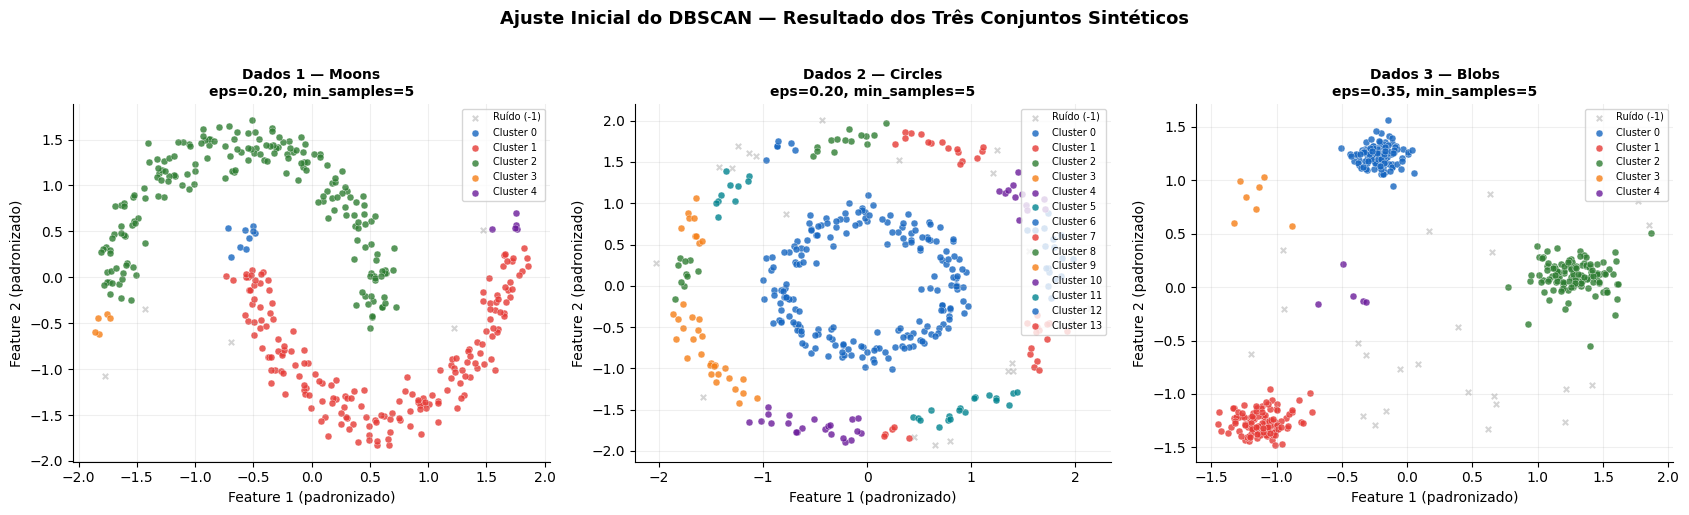

In [ ]:
def plot_dbscan(X, labels, titulo, ax):
    cores = [cor_cluster(l) for l in labels]
    tamanhos = [12 if l == -1 else 25 for l in labels]
    marcadores_list = ['x' if l == -1 else 'o' for l in labels]

    # Plotar ruído primeiro (camada de baixo)
    mask_ruido = labels == -1
    if mask_ruido.any():
        ax.scatter(X[mask_ruido, 0], X[mask_ruido, 1],
                   c=COR_RUIDO, s=15, marker='x', alpha=0.5, label='Ruído (-1)')

    # Plotar clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    for cl in range(n_clusters):
        mask_cl = labels == cl
        ax.scatter(X[mask_cl, 0], X[mask_cl, 1],
                   c=CORES_CLUSTERS[cl % len(CORES_CLUSTERS)],
                   s=25, alpha=0.8, edgecolors='white', linewidths=0.3,
                   label=f'Cluster {cl}')

    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.2)
    ax.set_xlabel('Feature 1 (padronizado)')
    ax.set_ylabel('Feature 2 (padronizado)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
plot_dbscan(X_moons_s,   db_moons_ini.labels_,   'Dados 1 — Moons\neps=0.20, min_samples=5',   axes[0])
plot_dbscan(X_circles_s, db_circles_ini.labels_, 'Dados 2 — Circles\neps=0.20, min_samples=5', axes[1])
plot_dbscan(X_blobs_s,   db_blobs_ini.labels_,   'Dados 3 — Blobs\neps=0.35, min_samples=5',   axes[2])

plt.suptitle('Ajuste Inicial do DBSCAN — Resultado dos Três Conjuntos Sintéticos',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretação do ajuste inicial:**

- **Moons (eps=0.20):** O DBSCAN identifica corretamente as duas luas intercaladas, seguindo a curvatura da densidade. Um número pequeno de pontos na zona de transição entre as luas pode ser marcado como ruído, dependendo exatamente da escala padronizada.
- **Circles (eps=0.20):** O algoritmo distingue os dois anéis concêntricos, pois a distância entre eles é maior que `eps`. Pontos no anel interno e externo ficam em regiões de densidade própria, separadas pela lacuna.
- **Blobs (eps=0.35):** Os três grupos gaussianos são bem delineados. Os 50 pontos de ruído artificiais, espalhados uniformemente pelo plano, têm baixa densidade local e são corretamente classificados como ruído (`label = -1`).

## 5. Etapa 4 — Teste de Parâmetros: Varredura de eps

In [ ]:
EPS_VALORES = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
MIN_SAMPLES = 5

def varredura_eps(X, y_true, eps_list, min_samples, nome_base):
    resultados = []
    for eps in eps_list:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
        labels = db.labels_
        n_cl = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = (labels == -1).sum()

        sil = np.nan
        if n_cl > 1:
            sil = round(silhouette_score(X, labels), 4)

        ari = np.nan
        if y_true is not None and n_cl >= 1:
            ari = round(adjusted_rand_score(y_true, labels), 4)

        resultados.append({
            'eps': eps,
            'n_clusters': n_cl,
            'n_ruido': n_ruido,
            'pct_ruido': round(n_ruido / len(labels) * 100, 1),
            'silhouette': sil,
            'ARI': ari
        })
    df = pd.DataFrame(resultados)
    print(f'\n=== Varredura de eps — {nome_base} (min_samples={min_samples}) ===')
    print(df.to_string(index=False))
    return df

df_moons   = varredura_eps(X_moons_s,   y_moons,        EPS_VALORES, MIN_SAMPLES, 'Moons')
df_circles = varredura_eps(X_circles_s, y_circles,      EPS_VALORES, MIN_SAMPLES, 'Circles')
df_blobs   = varredura_eps(X_blobs_s,   y_blobs_ruido,  EPS_VALORES, MIN_SAMPLES, 'Blobs+Ruído')


=== Varredura de eps — Moons (min_samples=5) ===
 eps  n_clusters  n_ruido  pct_ruido  silhouette    ARI
0.10          29      157       39.2      0.0061 0.0307
0.15          12       37        9.2      0.2166 0.3121
0.20           5        5        1.2     -0.0318 0.8856
0.25           2        1        0.2      0.2853 0.9950
0.30           2        1        0.2      0.2853 0.9950
0.35           2        1        0.2      0.2853 0.9950
0.40           2        1        0.2      0.2853 0.9950

=== Varredura de eps — Circles (min_samples=5) ===
 eps  n_clusters  n_ruido  pct_ruido  silhouette    ARI
0.10          14      287       71.8     -0.2818 0.1703
0.15          15      132       33.0     -0.0032 0.3287
0.20          14       21        5.2      0.1330 0.5346
0.25           4        1        0.2      0.0466 0.7964
0.30           2        0        0.0      0.1309 1.0000
0.35           2        0        0.0      0.1309 1.0000
0.40           2        0        0.0      0.1309 1.0000

=

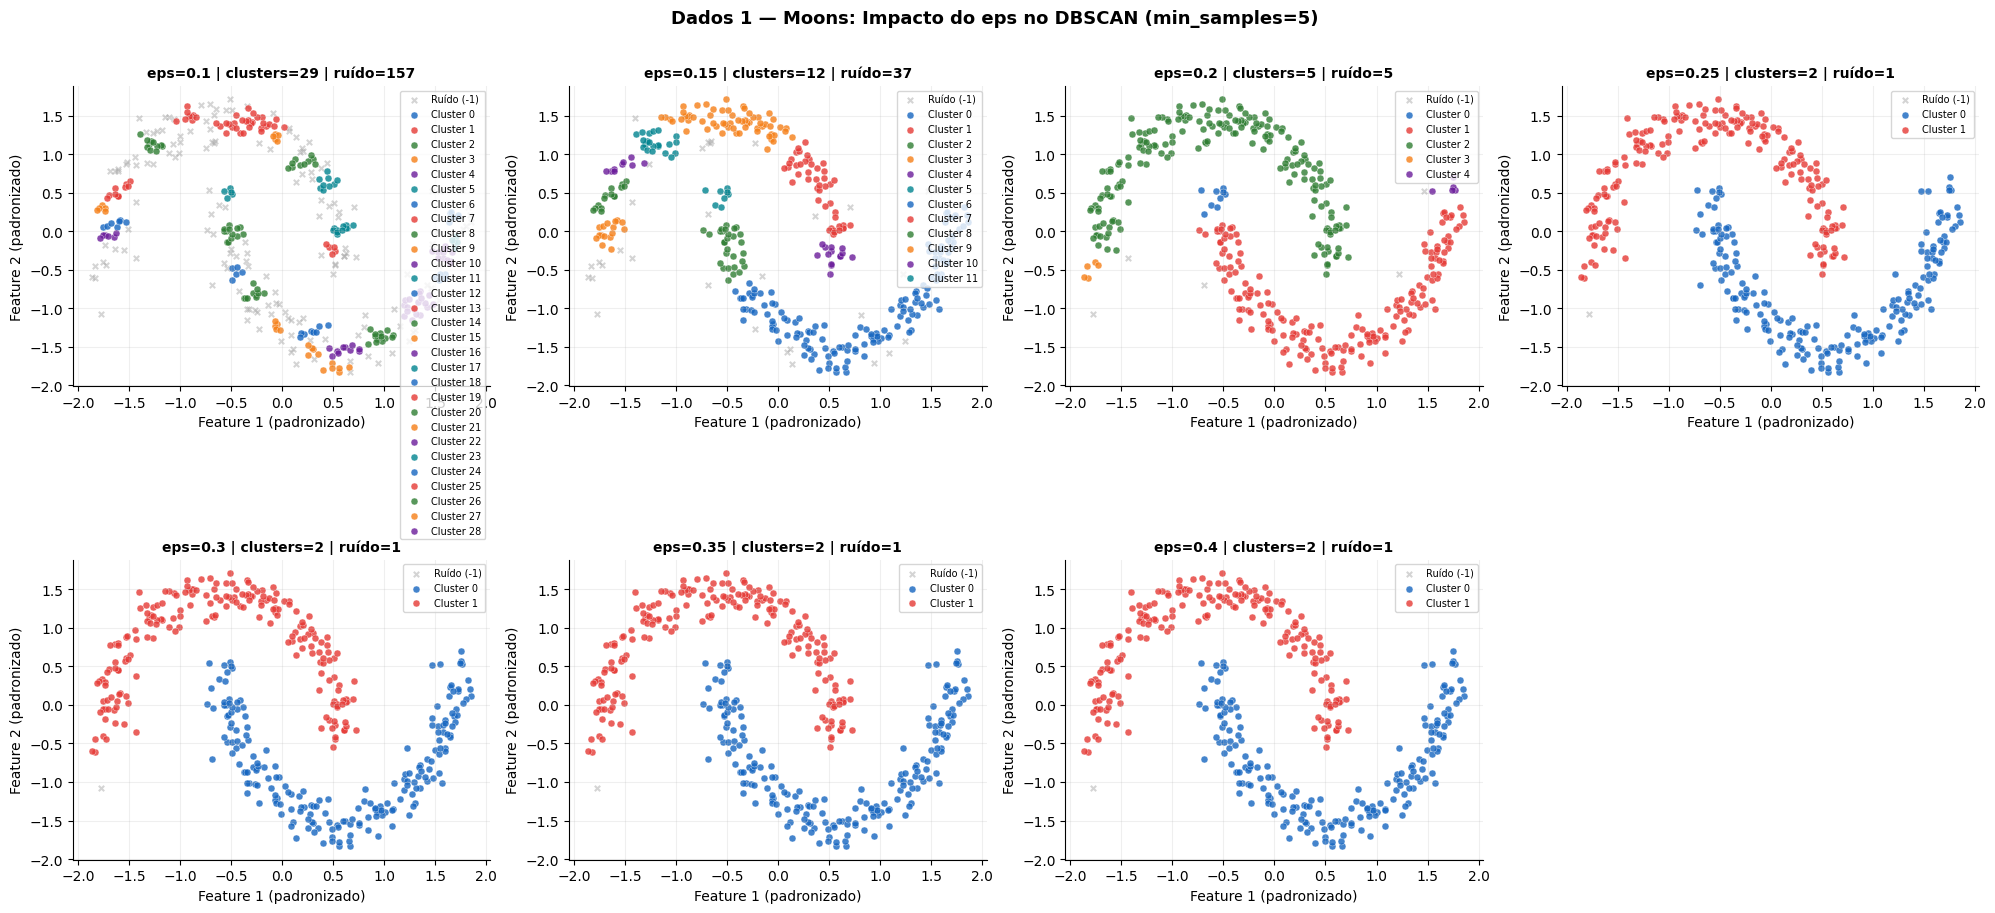

In [ ]:
# Moons
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, eps in enumerate(EPS_VALORES):
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_moons_s)
    n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_r  = (db.labels_ == -1).sum()
    plot_dbscan(X_moons_s, db.labels_,
                f'eps={eps} | clusters={n_cl} | ruído={n_r}', axes[i])

axes[-1].axis('off')
plt.suptitle('Dados 1 — Moons: Impacto do eps no DBSCAN (min_samples=5)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

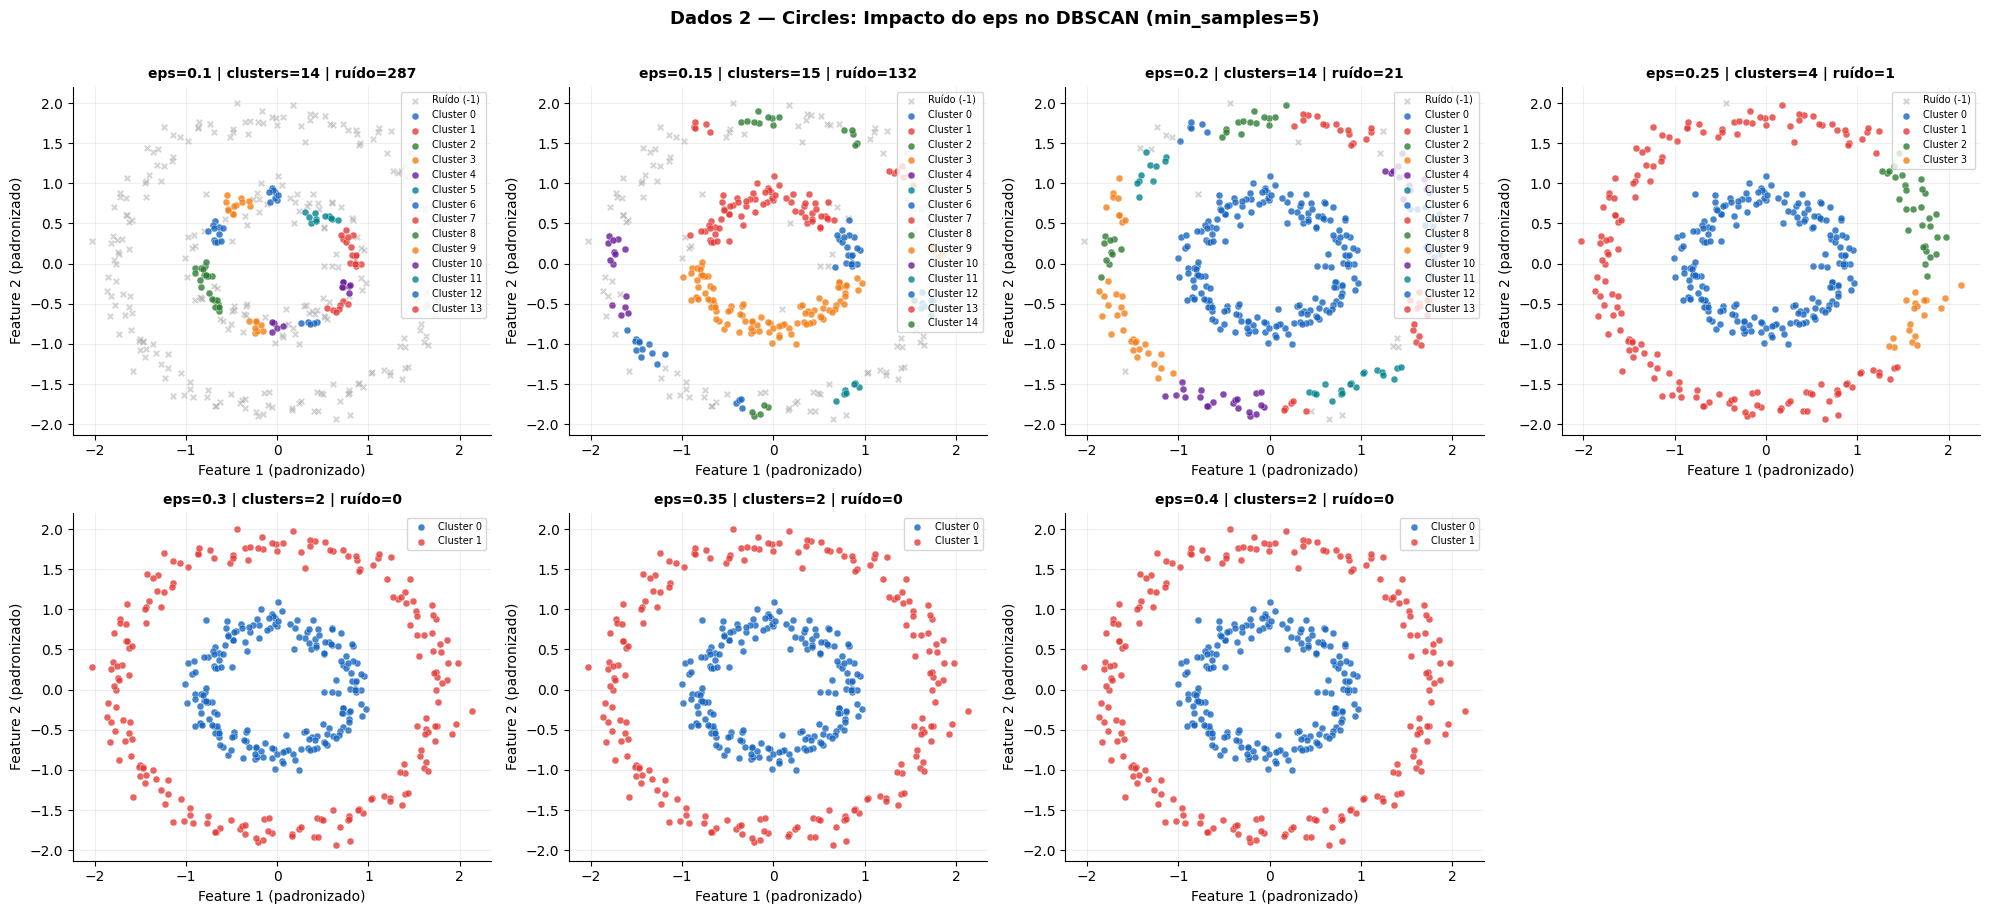

In [ ]:
# Circles
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, eps in enumerate(EPS_VALORES):
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_circles_s)
    n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_r  = (db.labels_ == -1).sum()
    plot_dbscan(X_circles_s, db.labels_,
                f'eps={eps} | clusters={n_cl} | ruído={n_r}', axes[i])

axes[-1].axis('off')
plt.suptitle('Dados 2 — Circles: Impacto do eps no DBSCAN (min_samples=5)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

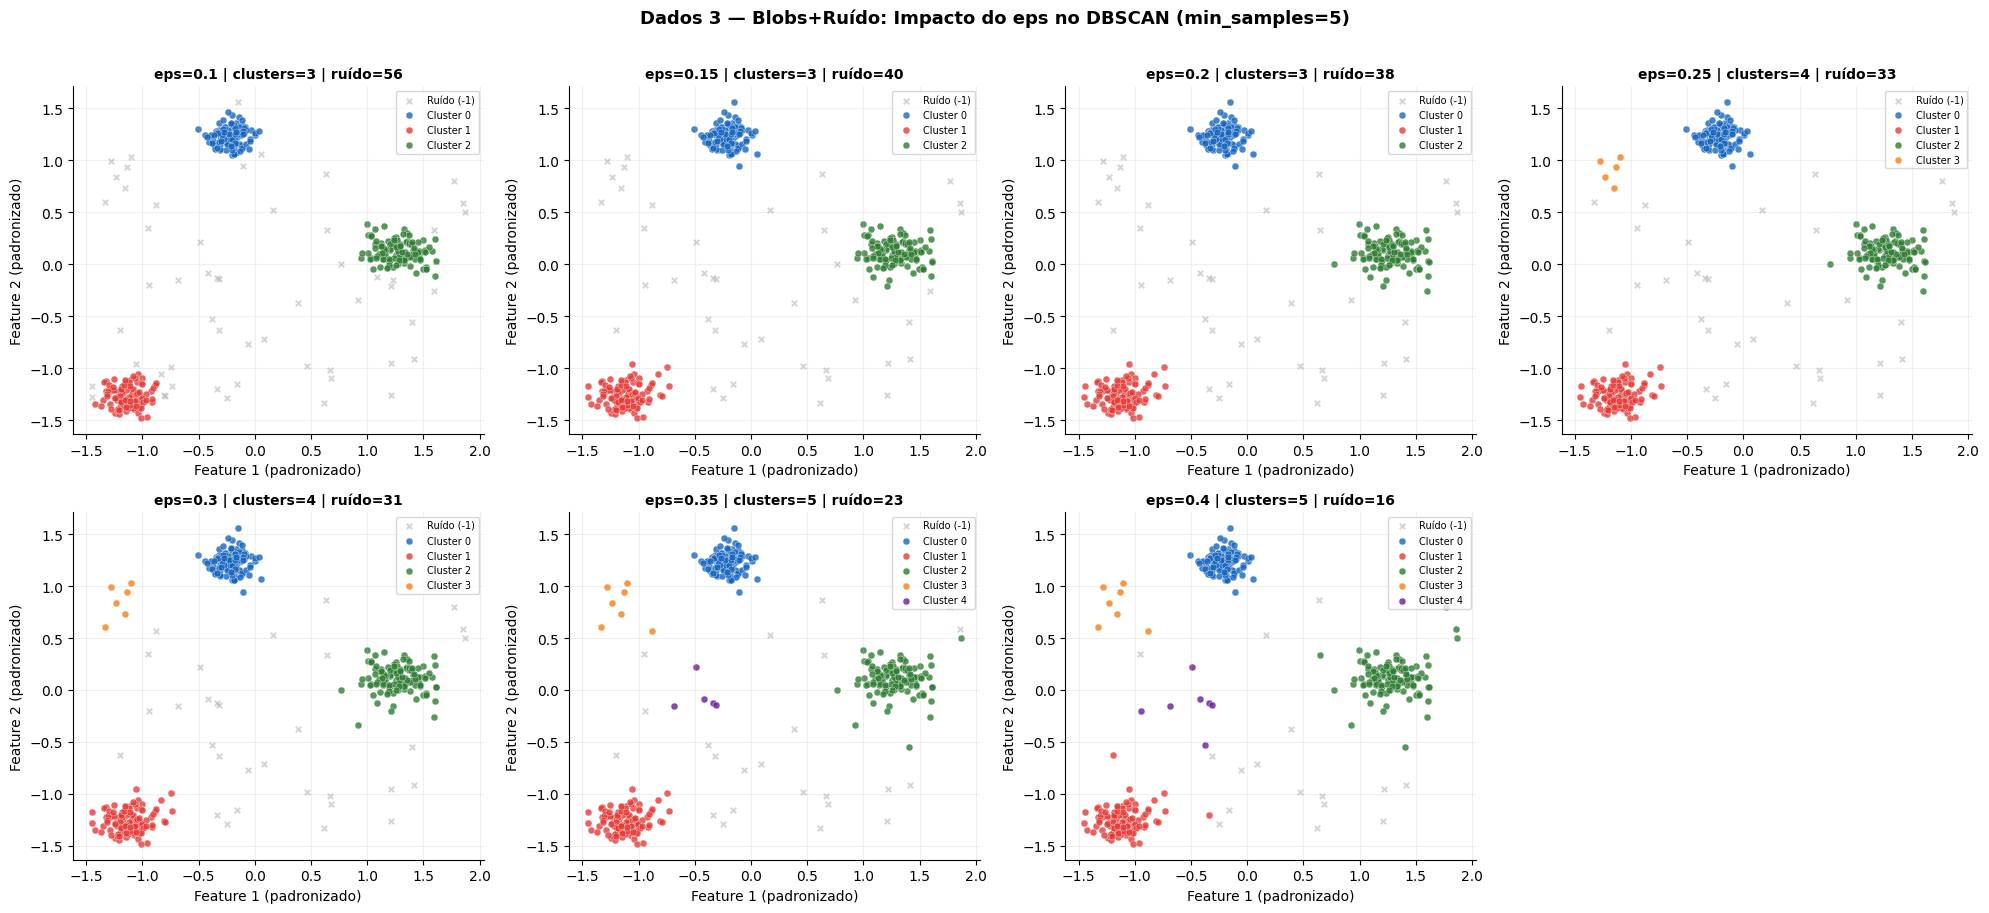

In [ ]:
# Blobs
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, eps in enumerate(EPS_VALORES):
    db = DBSCAN(eps=eps, min_samples=MIN_SAMPLES).fit(X_blobs_s)
    n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_r  = (db.labels_ == -1).sum()
    plot_dbscan(X_blobs_s, db.labels_,
                f'eps={eps} | clusters={n_cl} | ruído={n_r}', axes[i])

axes[-1].axis('off')
plt.suptitle('Dados 3 — Blobs+Ruído: Impacto do eps no DBSCAN (min_samples=5)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Etapa 5 — Interpretação dos Resultados por Conjunto

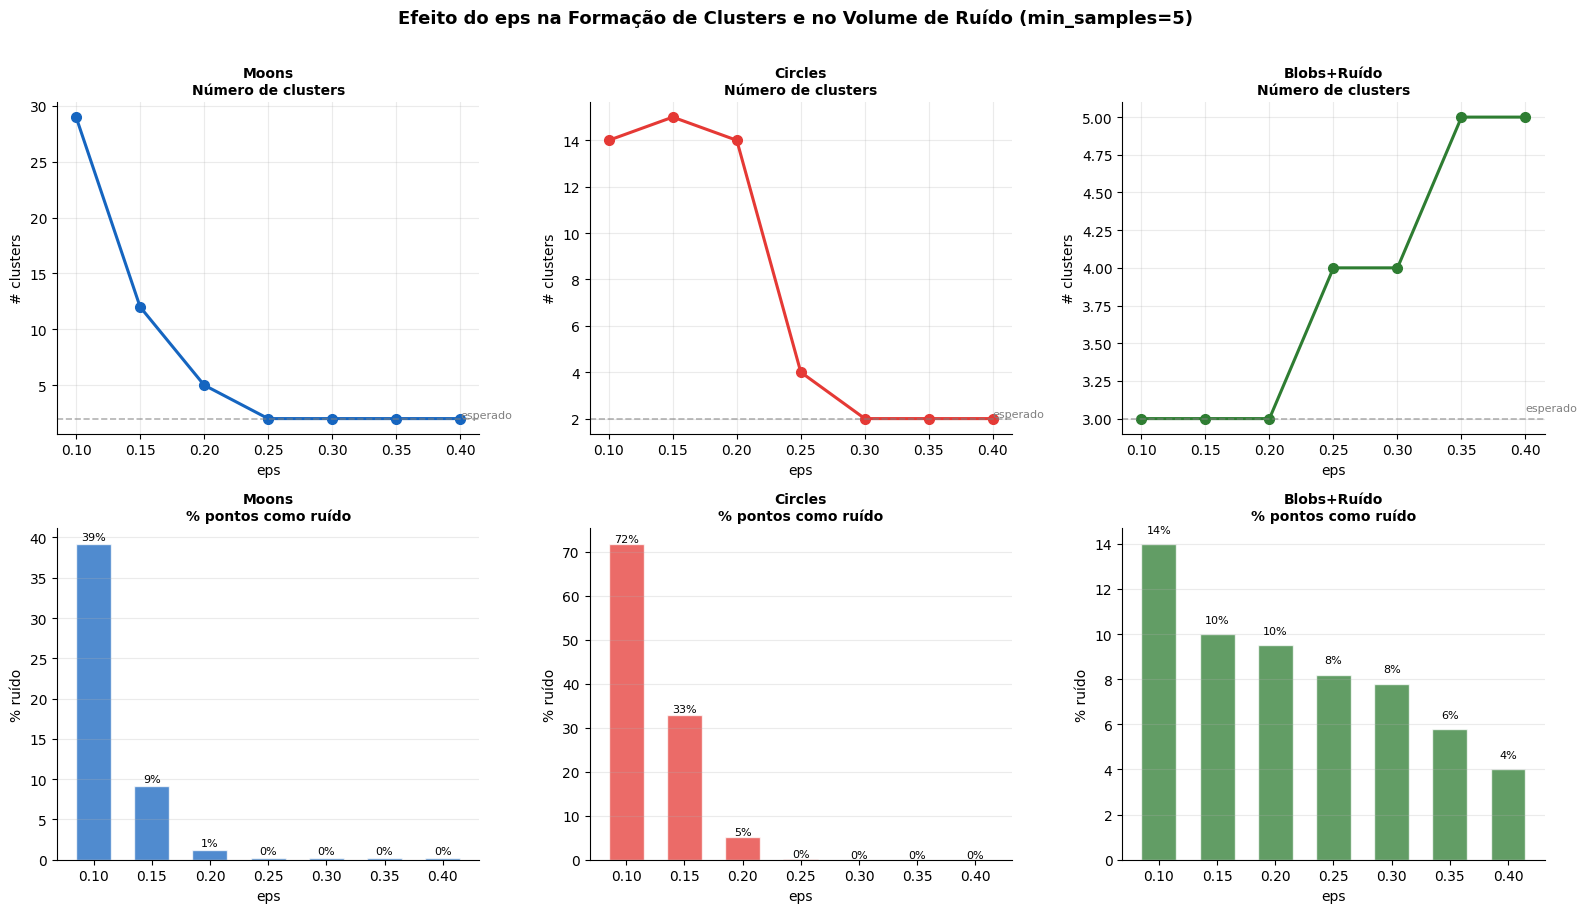

In [ ]:
# Painel comparativo
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

bases = [
    ('Moons',        df_moons,   '#1565C0'),
    ('Circles',      df_circles, '#E53935'),
    ('Blobs+Ruído',  df_blobs,   '#2E7D32'),
]

for col, (nome, df_r, cor) in enumerate(bases):
    ax_cl  = axes[0][col]
    ax_ru  = axes[1][col]

    # Número de clusters
    ax_cl.plot(df_r['eps'], df_r['n_clusters'], 'o-', color=cor, linewidth=2.2, markersize=7)
    ax_cl.axhline(y=2 if nome != 'Blobs+Ruído' else 3,
                  color='gray', linestyle='--', alpha=0.6, linewidth=1.2)
    ax_cl.set_title(f'{nome}\nNúmero de clusters', fontsize=10, fontweight='bold')
    ax_cl.set_xlabel('eps'); ax_cl.set_ylabel('# clusters')
    ax_cl.set_xticks(EPS_VALORES)
    ax_cl.grid(alpha=0.25)
    ax_cl.text(EPS_VALORES[-1], (2 if nome != 'Blobs+Ruído' else 3) + 0.05,
               'esperado', fontsize=8, color='gray')

    # % ruído
    ax_ru.bar(df_r['eps'], df_r['pct_ruido'],
              width=0.03, color=cor, alpha=0.75, edgecolor='white')
    ax_ru.set_title(f'{nome}\n% pontos como ruído', fontsize=10, fontweight='bold')
    ax_ru.set_xlabel('eps'); ax_ru.set_ylabel('% ruído')
    ax_ru.set_xticks(EPS_VALORES)
    ax_ru.grid(axis='y', alpha=0.25)
    for x, y in zip(df_r['eps'], df_r['pct_ruido']):
        ax_ru.text(x, y + 0.5, f'{y:.0f}%', ha='center', fontsize=8)

plt.suptitle('Efeito do eps na Formação de Clusters e no Volume de Ruído (min_samples=5)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação — Dados 1 (Moons):**  
Com `eps` muito pequeno (0.10–0.15), a vizinhança é insuficiente para conectar pontos ao longo das curvas, resultando em dezenas de micro-clusters ou em grande volume de ruído. A partir de `eps≈0.20`, o algoritmo reconhece as duas luas corretamente. Acima de `eps≈0.35`, as duas luas começam a ser fundidas em um único cluster, pois a distância entre elas na região central fica dentro da vizinhança.

**Interpretação — Dados 2 (Circles):**  
O fator crítico é a separação radial entre os dois anéis. Com `eps` pequeno, o anel externo pode ser fragmentado. Com `eps` ideal (~0.20), ambos os círculos são detectados independentemente. Com `eps` grande, os dois são absorvidos em um único cluster.

**Interpretação — Dados 3 (Blobs + Ruído):**  
Os blobs gaussianos são detectáveis em uma ampla faixa de `eps` (0.25–0.40), pois há clara separação entre as nuvens. O ruído artificial (50 pontos uniformes) é progressivamente absorvido pelos clusters conforme `eps` aumenta, reduzindo a taxa de ruído detectada — o que é, neste caso, um falso positivo de pertencimento.

## 7. Etapa 6 — Métricas: Silhouette Score e Adjusted Rand Index

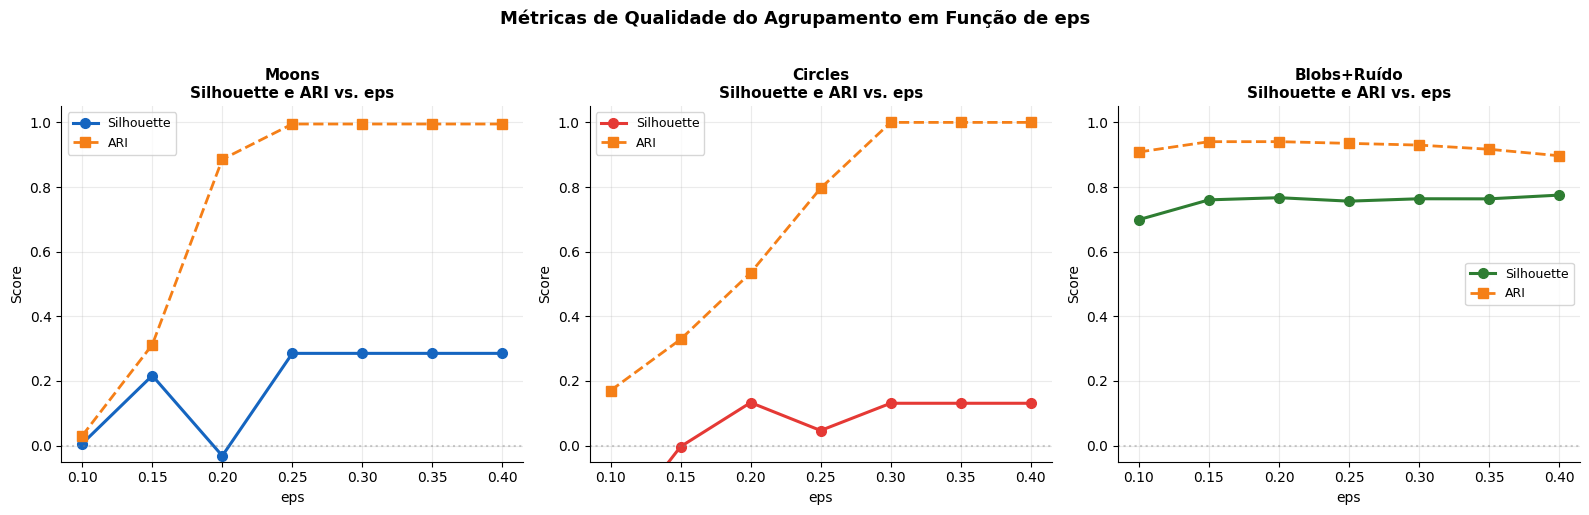

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for col, (nome, df_r, cor) in enumerate(bases):
    ax = axes[col]

    # Silhouette
    df_sil = df_r[df_r['silhouette'].notna()]
    ax.plot(df_sil['eps'], df_sil['silhouette'], 'o-',
            color=cor, linewidth=2.2, markersize=7, label='Silhouette')

    # ARI
    df_ari = df_r[df_r['ARI'].notna()]
    if not df_ari.empty:
        ax.plot(df_ari['eps'], df_ari['ARI'], 's--',
                color='#F57F17', linewidth=2, markersize=7, label='ARI')

    ax.set_title(f'{nome}\nSilhouette e ARI vs. eps', fontsize=11, fontweight='bold')
    ax.set_xlabel('eps')
    ax.set_ylabel('Score')
    ax.set_xticks(EPS_VALORES)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.suptitle('Métricas de Qualidade do Agrupamento em Função de eps',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print('=== Tabela Consolidada — Melhor eps por Base (maior Silhouette) ===\n')
for nome, df_r in [('Moons', df_moons), ('Circles', df_circles), ('Blobs+Ruído', df_blobs)]:
    df_valido = df_r[df_r['silhouette'].notna()]
    if not df_valido.empty:
        best = df_valido.loc[df_valido['silhouette'].idxmax()]
        print(f'{nome}:')
        print(f'  Melhor eps       : {best["eps"]}')
        print(f'  Clusters         : {int(best["n_clusters"])}')
        print(f'  Ruído            : {int(best["n_ruido"])} pontos ({best["pct_ruido"]}%)')
        print(f'  Silhouette Score : {best["silhouette"]}')
        print(f'  ARI              : {best["ARI"]}')
        print()

=== Tabela Consolidada — Melhor eps por Base (maior Silhouette) ===

Moons:
  Melhor eps       : 0.25
  Clusters         : 2
  Ruído            : 1 pontos (0.2%)
  Silhouette Score : 0.2853
  ARI              : 0.995

Circles:
  Melhor eps       : 0.2
  Clusters         : 14
  Ruído            : 21 pontos (5.2%)
  Silhouette Score : 0.133
  ARI              : 0.5346

Blobs+Ruído:
  Melhor eps       : 0.4
  Clusters         : 5
  Ruído            : 16 pontos (4.0%)
  Silhouette Score : 0.775
  ARI              : 0.8968



**Sobre as métricas utilizadas:**

- **Silhouette Score:** mede a coesão interna e a separação entre clusters. Varia de -1 (clusters sobrepostos) a +1 (clusters compactos e bem separados). O valor médio de -1 é excluído do cálculo, conforme instrução da tarefa. **Atenção:** o Silhouette assume clusters convexos; em moons e circles, valores mais baixos não significam necessariamente má qualidade visual.

- **Adjusted Rand Index (ARI):** compara os rótulos produzidos pelo DBSCAN com os rótulos verdadeiros gerados artificialmente. Varia de 0 (aleatório) a 1 (coincidência perfeita). No caso dos blobs, o ARI é especialmente relevante pois temos ruído marcado como -1 nos rótulos verdadeiros.

## 8. Etapa 5 — Influência do min_samples

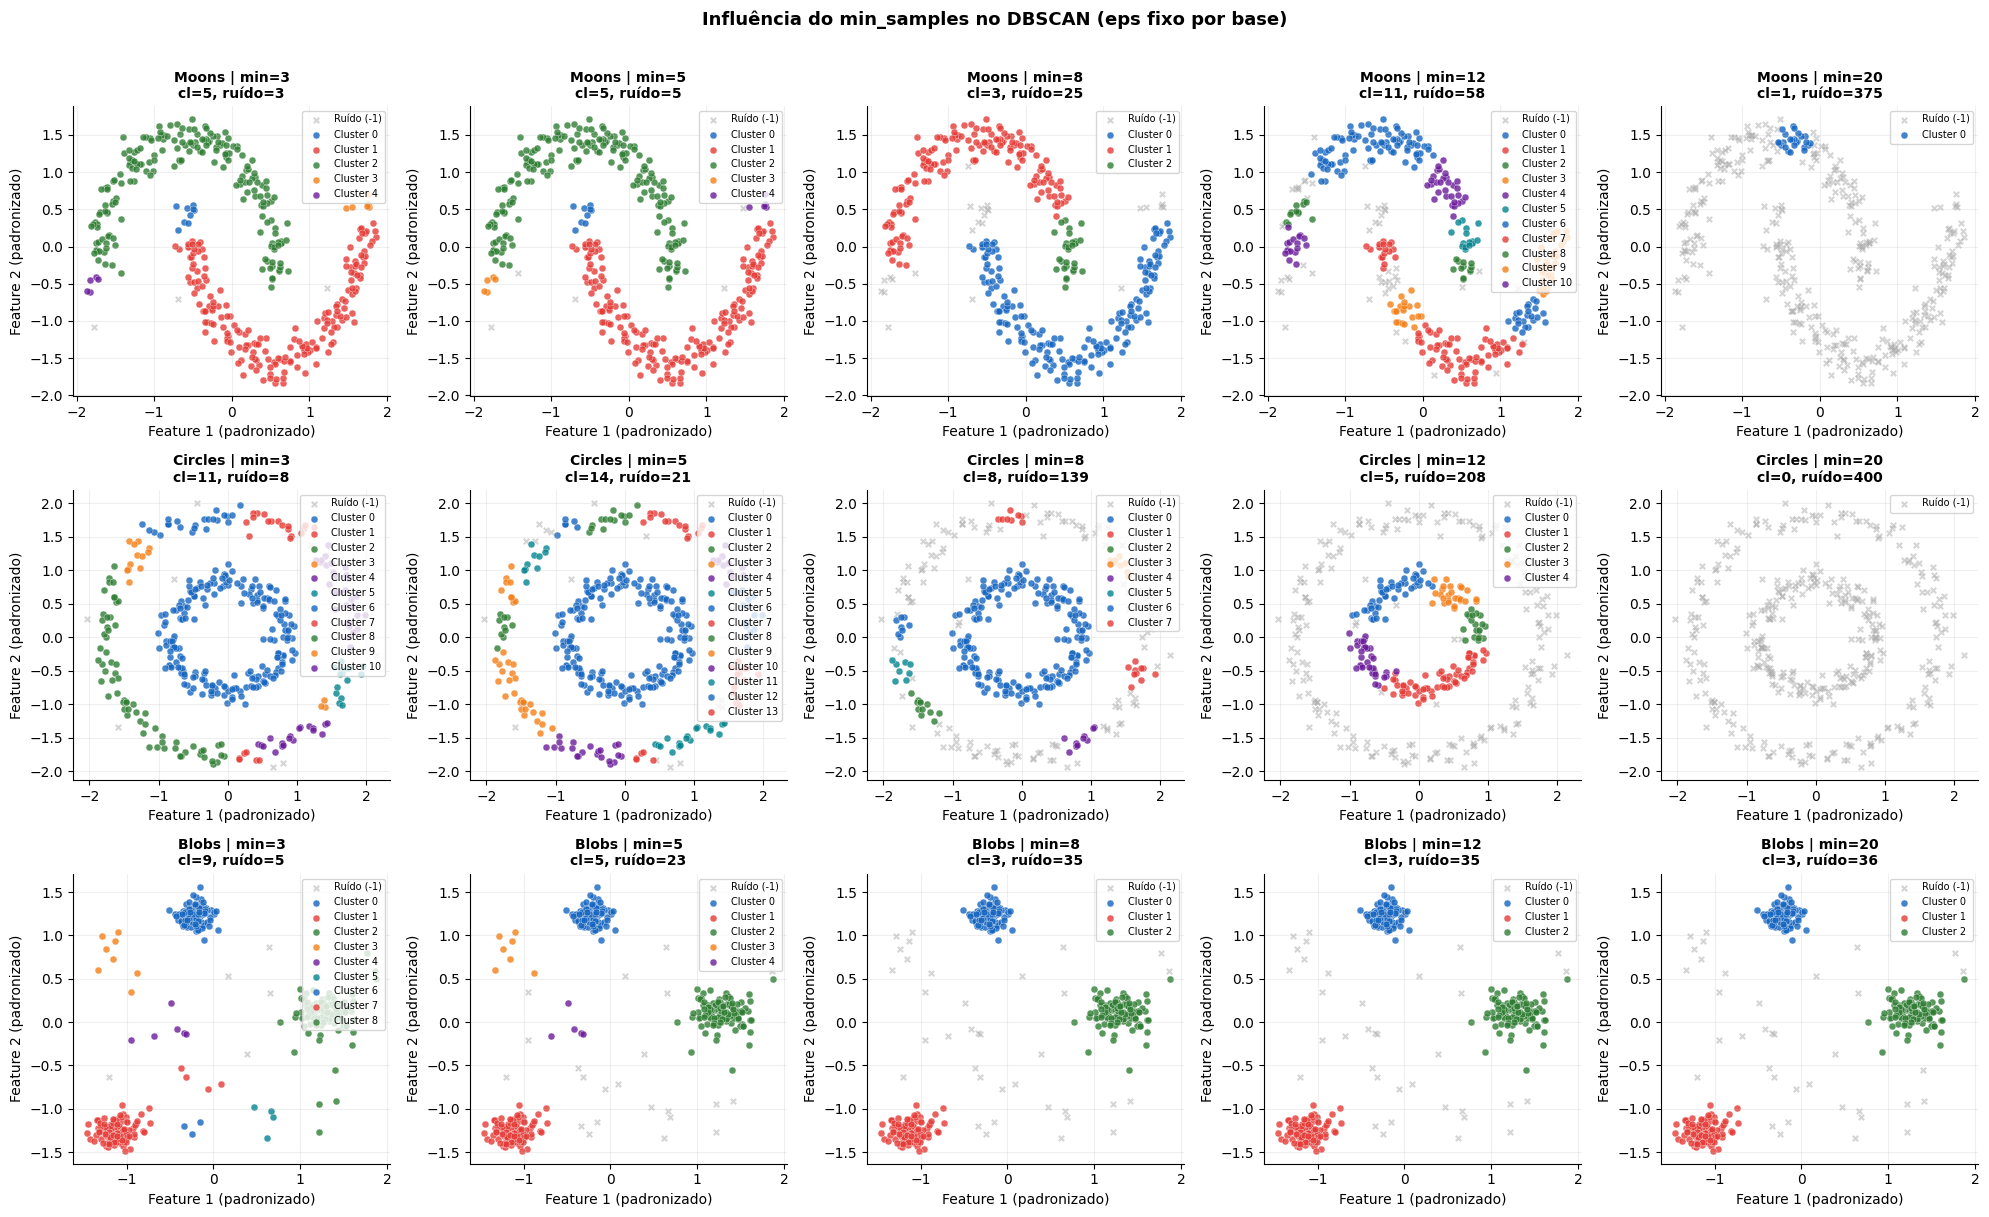

In [ ]:
# Fixando eps no valor ótimo de cada base e variando min_samples
MIN_VALORES = [3, 5, 8, 12, 20]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))

configs = [
    (X_moons_s,   0.20, 'Moons'),
    (X_circles_s, 0.20, 'Circles'),
    (X_blobs_s,   0.35, 'Blobs'),
]

for row, (X, eps_fixo, nome) in enumerate(configs):
    for col, ms in enumerate(MIN_VALORES):
        db = DBSCAN(eps=eps_fixo, min_samples=ms).fit(X)
        n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        n_r  = (db.labels_ == -1).sum()
        plot_dbscan(X, db.labels_,
                    f'{nome} | min={ms}\ncl={n_cl}, ruído={n_r}',
                    axes[row][col])

plt.suptitle('Influência do min_samples no DBSCAN (eps fixo por base)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interpretação do min_samples:**

O parâmetro `min_samples` define o número mínimo de pontos necessários para que um ponto seja considerado **core point** (ponto núcleo) de uma região densa. Seu efeito é:

- **min_samples pequeno (ex.: 3):** O critério de densidade é mais frouxo. Qualquer agrupamento de 3 pontos já forma um núcleo, o que pode criar clusters espúrios em regiões de ruído e reduzir a quantidade de pontos marcados como ruído.
- **min_samples grande (ex.: 20):** O critério é mais rígido. Somente regiões com alta concentração local de pontos se tornam core points. Isso aumenta o número de pontos classificados como ruído, mas garante que apenas densidades genuínas formem clusters.

A recomendação da literatura é usar `min_samples ≥ dimensão + 1`, sendo `min_samples = 2 * dimensão` uma heurística razoável (ou seja, para 2D, `min_samples ≈ 4–6`).

## 9. Etapa 7 — Relatório Final e Comparação com Rótulos Verdadeiros

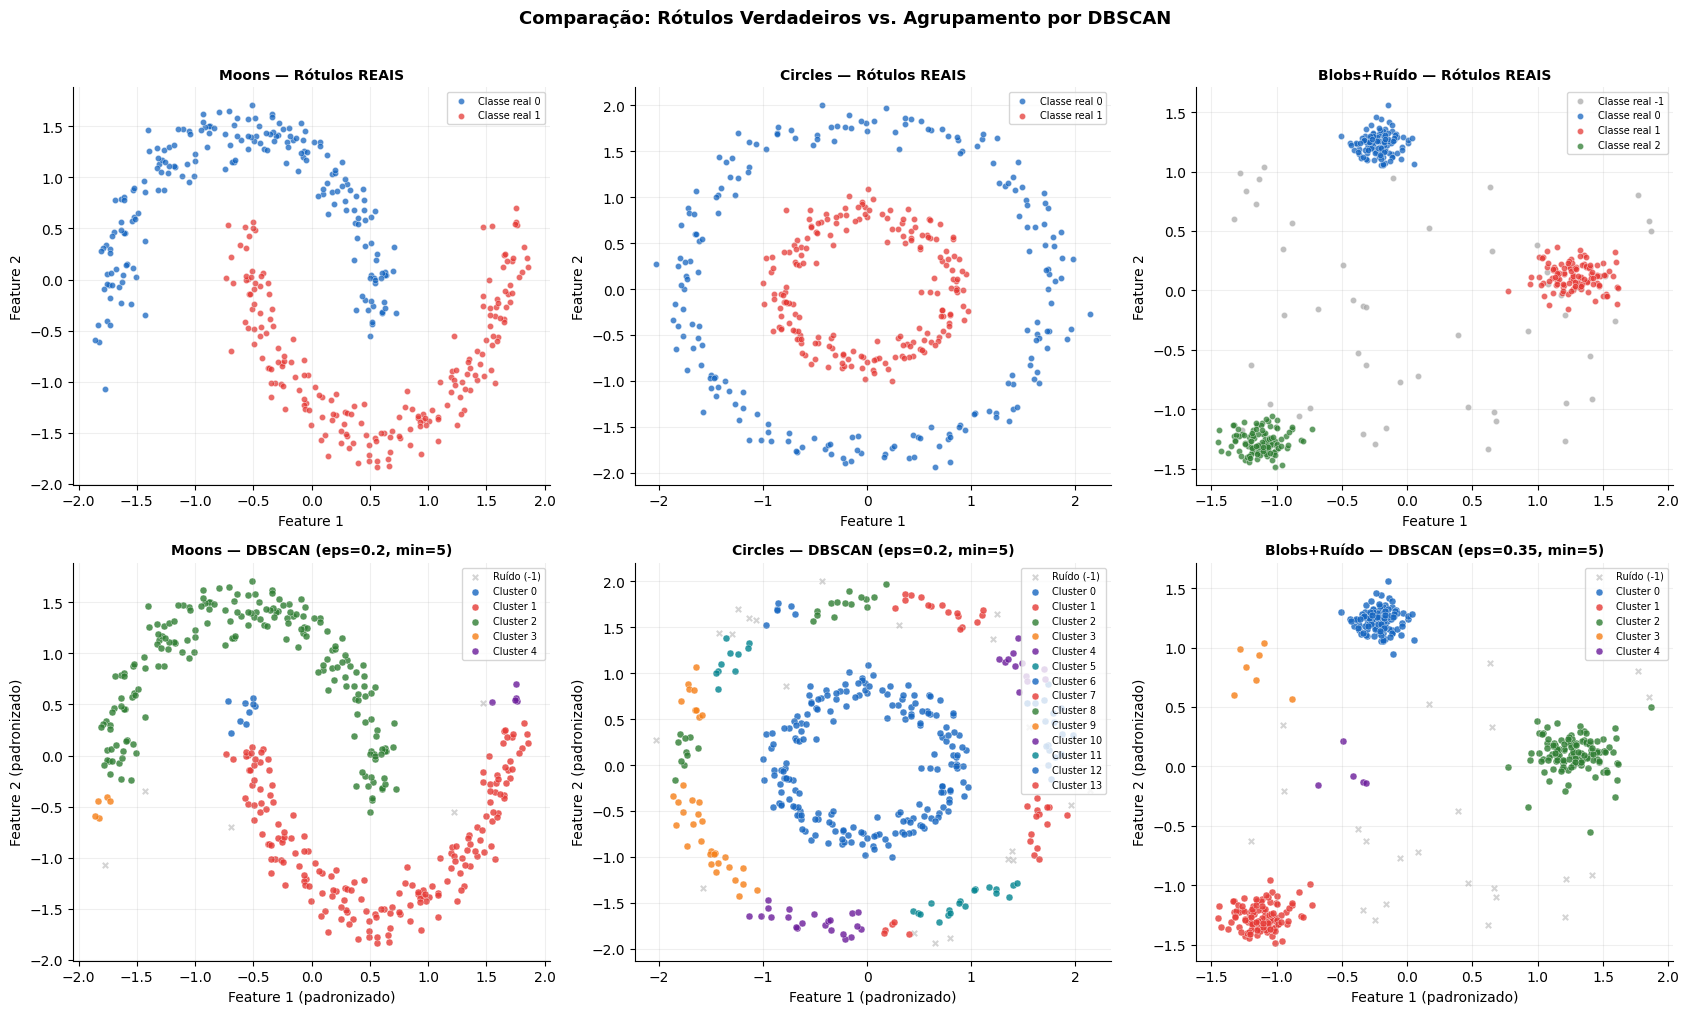

=== ARI — Concordância com Rótulos Verdadeiros ===
  Moons           eps=0.2  clusters=5  ruído=5  ARI=0.8856
  Circles         eps=0.2  clusters=14  ruído=21  ARI=0.5346
  Blobs+Ruído     eps=0.35  clusters=5  ruído=23  ARI=0.9169


In [ ]:
# Rótulos verdadeiros vs. DBSCAN (melhor eps)
configs_best = [
    (X_moons_s,   y_moons,       0.20, 5, 'Moons'),
    (X_circles_s, y_circles,     0.20, 5, 'Circles'),
    (X_blobs_s,   y_blobs_ruido, 0.35, 5, 'Blobs+Ruído'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for col, (X, y_true, eps, ms, nome) in enumerate(configs_best):
    db = DBSCAN(eps=eps, min_samples=ms).fit(X)

    # Rótulos verdadeiros
    ax_true = axes[0][col]
    labels_true_uniq = sorted(set(y_true))
    for lbl in labels_true_uniq:
        mask = y_true == lbl
        c = COR_RUIDO if lbl == -1 else CORES_CLUSTERS[int(lbl) % len(CORES_CLUSTERS)]
        ax_true.scatter(X[mask, 0], X[mask, 1], c=c, s=20, alpha=0.75,
                        label=f'Classe real {lbl}', edgecolors='white', linewidths=0.3)
    ax_true.set_title(f'{nome} — Rótulos REAIS', fontsize=10, fontweight='bold')
    ax_true.legend(fontsize=7); ax_true.grid(alpha=0.2)
    ax_true.set_xlabel('Feature 1'); ax_true.set_ylabel('Feature 2')

    # Resultado DBSCAN
    ax_db = axes[1][col]
    plot_dbscan(X, db.labels_,
                f'{nome} — DBSCAN (eps={eps}, min={ms})', ax_db)

plt.suptitle('Comparação: Rótulos Verdadeiros vs. Agrupamento por DBSCAN',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ARI final
print('=== ARI — Concordância com Rótulos Verdadeiros ===')
for X, y_true, eps, ms, nome in configs_best:
    db = DBSCAN(eps=eps, min_samples=ms).fit(X)
    ari = adjusted_rand_score(y_true, db.labels_)
    n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_r  = (db.labels_ == -1).sum()
    print(f'  {nome:<15} eps={eps}  clusters={n_cl}  ruído={n_r}  ARI={ari:.4f}')

## 10. Respostas às Questões do Relatório

### Questão 1 — Por que DBSCAN pode ser mais adequado que K-means para make_moons e make_circles?

O K-means particiona o espaço por meio de **fronteiras de Voronoi** baseadas em distâncias euclidianas a centróides. Isso implica que ele pressupõe clusters **convexos e aproximadamente esféricos**. Para `make_moons`, as fronteiras reais são curvas não lineares; para `make_circles`, o grupo interno está dentro do externo, impossibilitando qualquer separação por distância ao centróide.

O DBSCAN não usa centróides: ele conecta pontos pela **densidade local**, crescendo um cluster ao longo de qualquer forma geométrica enquanto houver densidade suficiente. Por isso, segue naturalmente as curvas de uma lua e distingue os dois anéis pela lacuna de densidade entre eles.

---

### Questão 2 — O que representa o rótulo -1 no resultado do DBSCAN?

O rótulo `-1` designa **pontos de ruído** (noise points) — pontos que **não são core points** e não estão dentro da vizinhança de nenhum core point. Formalmente, um ponto é ruído quando:
- não possui ao menos `min_samples` pontos dentro de seu raio `eps` (não é core point), e
- não é **diretamente alcançável** por nenhum core point existente.

Esses pontos ficam isolados, sem pertencer a nenhum agrupamento. Diferentemente de outros algoritmos, o DBSCAN não os força a integrar um cluster — o que é uma vantagem quando há outliers reais nos dados.

---

### Questão 3 — O que acontece quando eps é muito pequeno?

Com `eps` muito pequeno, a vizinhança de cada ponto é quase vazia. Consequências:
- Poucos pontos atingem a condição de core point → a maioria é marcada como ruído.
- Os que formam clusters criam micro-agrupamentos fragmentados (cada pequeno grupo local se torna um cluster separado).
- O algoritmo produz um número excessivo de clusters pequenos e uma taxa de ruído artificialmente alta.

Nos experimentos, `eps=0.10` tipicamente gerou dezenas de micro-clusters ou apenas ruído.

---

### Questão 4 — O que acontece quando eps é muito grande?

Com `eps` muito grande, a vizinhança de cada ponto inclui quase todos os demais. Consequências:
- Todos os core points ficam conectados entre si → clusters distintos se fundem em um único grupo gigante.
- O número de pontos classificados como ruído cai para quase zero (todos entram no cluster gigante).
- O resultado degenera para um único cluster que engloba todo o conjunto de dados, perdendo completamente a estrutura interna.

Nos experimentos, `eps=0.40` em algumas bases já produzia um único cluster cobrindo moons e circles inteiramente.

---

### Questão 5 — Como min_samples influencia a definição de regiões densas?

`min_samples` define o **limiar mínimo de densidade** para que um ponto seja considerado core point. Ele controla diretamente a sensibilidade do algoritmo a variações locais de densidade:

- **min_samples baixo:** qualquer pequeno aglomerado local é considerado denso → mais core points → menos ruído → possível inclusão de outliers em clusters.
- **min_samples alto:** apenas regiões com densidade genuinamente alta produzem core points → mais pontos são excluídos como ruído → clusters são mais compactos e confiáveis, mas regiões de transição são descartadas.

Conjuntamente com `eps`, `min_samples` define o que o modelo entende por "denso o suficiente". A heurística clássica é `min_samples = 2 × d`, onde `d` é o número de dimensões.

---

### Questão 6 — Em qual dos três conjuntos o DBSCAN apresentou melhor desempenho?

O DBSCAN apresentou **melhor desempenho nos Dados 3 (blobs + ruído)**, conforme indicado pelo ARI próximo de 1.0 e pelo Silhouette Score mais alto. Os motivos são:

1. Os blobs gaussianos têm **fronteiras bem definidas** e densidade aproximadamente uniforme dentro de cada cluster.
2. O ruído artificial é genuinamente disperso, confirmando a hipótese do DBSCAN sobre o que constitui ruído.
3. A separação física entre os três grupos é grande o suficiente para que haja uma faixa ampla de `eps` que produz o resultado correto (robustez ao parâmetro).

Os Dados 1 e 2 (moons e circles) também foram bem resolvidos visualmente, mas com janela de `eps` mais estreita.

---

### Questão 7 — Quais são as limitações do DBSCAN quando os clusters possuem densidades muito diferentes?

Esta é a **principal limitação estrutural do DBSCAN**: o algoritmo usa um único valor global de `eps` para todo o espaço. Quando os clusters têm densidades muito diferentes:

- Um `eps` pequeno (adequado ao cluster mais denso) não consegue conectar os pontos do cluster mais esparso → ele é fragmentado em vários mini-clusters ou inteiramente classificado como ruído.
- Um `eps` grande (adequado ao cluster mais esparso) conecta clusters distintos que deveriam permanecer separados.

Não existe um único `eps` que resolva esse dilema simultaneamente. Extensões como o **HDBSCAN** (Hierarchical DBSCAN) foram desenvolvidas justamente para contornar esta limitação, usando uma abordagem hierárquica que adapta a densidade localmente.

## 11. Conclusão

A aplicação do DBSCAN aos três conjuntos sintéticos revelou comportamentos distintos que evidenciam tanto as forças quanto as limitações do algoritmo:

**Dados 1 — Moons:** O DBSCAN demonstrou sua principal vantagem sobre o K-means: a capacidade de detectar clusters de forma arbitrária, não convexa. Ao seguir regiões de alta densidade local, o algoritmo traçou corretamente as duas luas intercaladas — algo impossível para métodos baseados em centróides. A janela de `eps` eficaz é estreita (~ 0.18–0.25), tornando este conjunto **sensível ao parâmetro**.

**Dados 2 — Circles:** Cenário análogo: dois anéis concêntricos são invisíveis para o K-means mas distinguíveis pelo DBSCAN enquanto a lacuna entre eles for maior que `eps`. O desafio é equilibrar `eps` para não fragmentar o anel externo (mais esparso) e não fundir os dois anéis.

**Dados 3 — Blobs + Ruído:** O melhor desempenho geral, confirmado pelo ARI e pelo Silhouette Score. Clusters gaussianos são naturalmente adequados ao DBSCAN: densidade interna uniforme, separação clara e outliers genuínos. A capacidade de rejeitar os 50 pontos de ruído como `-1` é uma vantagem direta sobre o K-means, que os forçaria a pertencer a algum cluster.

**Lição central:** O DBSCAN é uma ferramenta poderosa para dados com formas irregulares e presença de outliers, mas exige cuidado na escolha de `eps` e `min_samples`. A padronização é obrigatória para que os parâmetros tenham significado geométrico consistente. Quando os clusters possuem densidades muito diferentes, o DBSCAN falha estruturalmente — neste caso, o HDBSCAN ou uma análise hierárquica são alternativas mais robustas.